## Data Exploration

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
RAW_DIR = PROJECT_ROOT / "dataset/raw"
PROCESSED_DIR = PROJECT_ROOT / "dataset/processed"

df = pd.read_csv(RAW_DIR / 'kuhar.csv', header=None)
display(df.head())

print('Shape:', df.shape)
print('Label column (1800) unique values:', df.iloc[:, 1800].unique())
print('Null values in dataset:', df.isnull().sum().sum())

,0,1,2,3,4,5,6,7,8,9,...,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802
0,0.004230,-0.000280,-0.013906,-0.002544,0.027433,0.058300,0.051670,0.071857,0.080653,0.047917,...,-0.016692,-0.018566,-0.017361,-0.017919,-0.016680,-0.016650,-0.013097,0,300,1
1,0.012482,0.032496,0.067856,0.071552,0.078103,0.040353,-0.001059,-0.018580,-0.026813,-0.011280,...,-0.008210,-0.010408,-0.011459,-0.011747,-0.010394,-0.008070,-0.004354,0,300,2
2,0.012127,0.028458,0.062075,0.052611,0.022942,-0.010017,-0.023151,-0.028515,0.005036,0.008450,...,0.000915,0.000771,-0.002560,-0.003020,-0.004190,0.000215,0.000850,0,300,3
3,0.052964,0.074319,0.110670,0.108490,0.091825,0.056989,0.029337,-0.016724,-0.042265,-0.053983,...,-0.001209,0.002878,0.000663,0.000982,-0.002148,-0.009200,-0.010653,0,300,4
4,-0.020462,-0.030787,-0.008617,0.008906,0.045046,0.042136,0.045037,0.045182,0.025113,0.021730,...,-0.006369,-0.006614,-0.004698,-0.007279,-0.006861,-0.006161,-0.006113,0,300,5


Shape: (20750, 1803)
Label column (1800) unique values: [ 0  1  2 10 11 12 13 14 15 16 17  3  4  5  6  7  8  9]
Null values in dataset: 0


Each row is one 3-second window. The first 1800 columns are sensor values (6 channels × 300 timesteps). Column 1800 is the activity label.

In [3]:
def make_channels(df):
    y = df.iloc[:, 1800].values.astype(np.int64)

    channels = []
    for ch in range(6):
        channels.append(df.iloc[:, ch*300:(ch+1)*300].values.astype(np.float32))
    X = np.stack(channels, axis=1)

    return X, y

X, y = make_channels(df)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {np.unique(y)}')
print(f'Value range: [{X.min():.2f}, {X.max():.2f}]')

X shape: (20750, 6, 300)
y shape: (20750,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Value range: [-173920.00, 189630.00]


In [4]:
# Class distribution
ACTIVITY_NAMES = {
    0: "Stand",       1: "Sit",          2: "Talk-sit",
    3: "Talk-stand",  4: "Stand-sit",    5: "Lay",
    6: "Lay-stand",   7: "Pick",         8: "Jump",
    9: "Push-up",    10: "Sit-up",      11: "Walk",
   12: "Walk-back",  13: "Walk-circle", 14: "Run",
   15: "Stair-up",   16: "Stair-down",  17: "Table-tennis",
}

counts = [np.sum(y == i) for i in range(18)]
names  = [ACTIVITY_NAMES[i] for i in range(18)]

print(f"Class with minimum samples: {names[np.argmin(counts)]} ({min(counts)})")
print(f"Class with maximum samples: {names[np.argmax(counts)]} ({max(counts)})")

Class with minimum samples: Walk-circle (259)
Class with maximum samples: Stand-sit (2178)


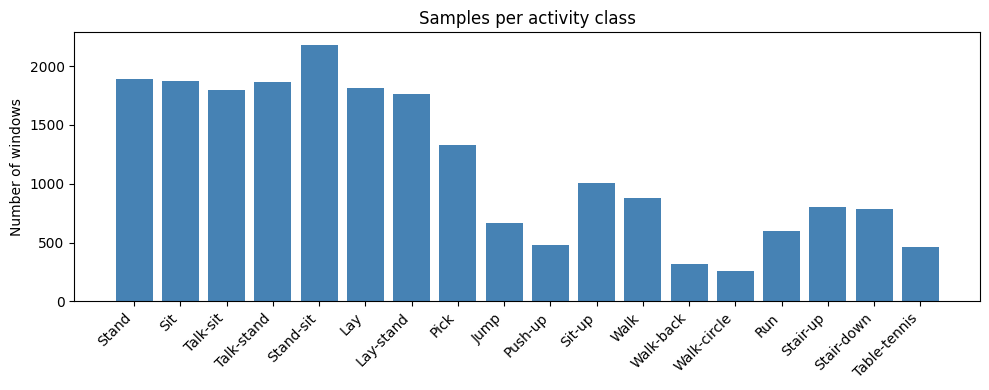

In [5]:
plt.figure(figsize=(10, 4))
plt.bar(names, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')

plt.ylabel('Number of windows')
plt.title('Samples per activity class')
plt.tight_layout()

plt.show()

## Raw signal visualization

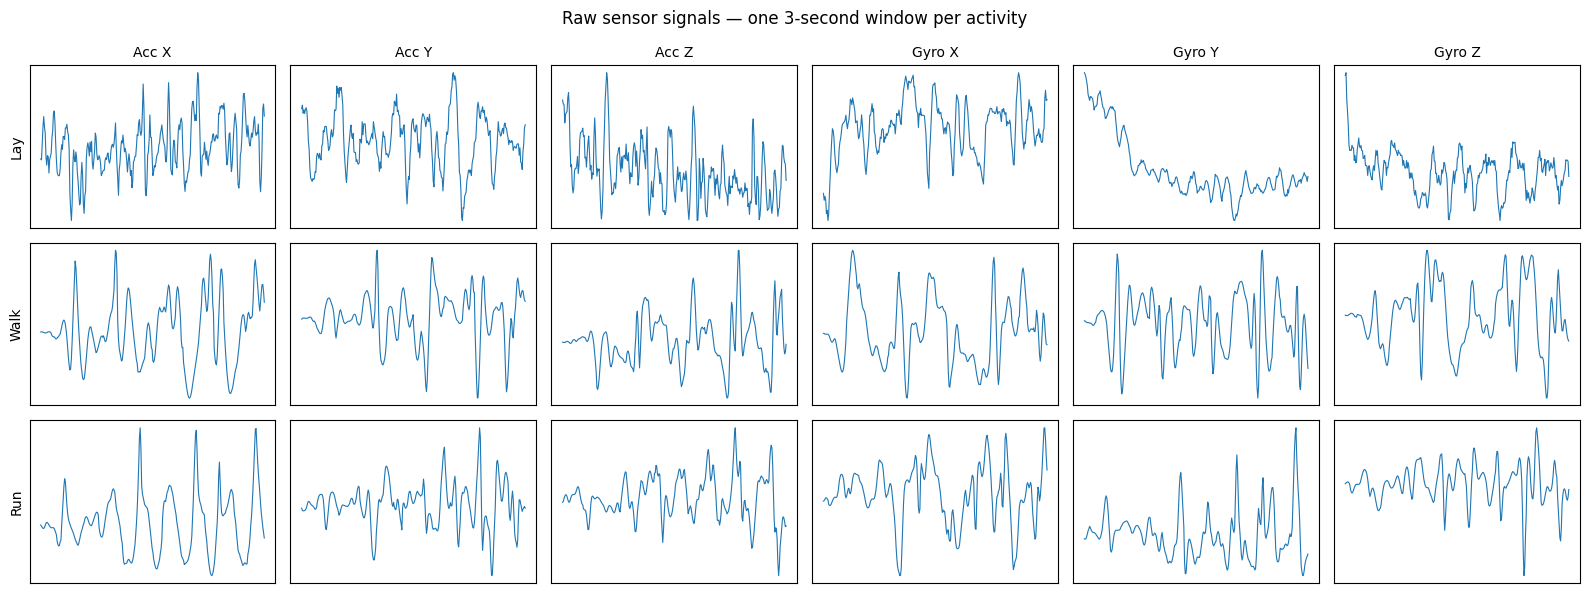

In [6]:
channel_names = ['Acc X', 'Acc Y', 'Acc Z', 'Gyro X', 'Gyro Y', 'Gyro Z']
activities    = [5, 11, 14] # Lay, Walk, Run

fig, axes = plt.subplots(3, 6, figsize=(16, 6))

for row, act in enumerate(activities):
    idx = np.where(y == act)[0][0]
    for col in range(6):
        axes[row, col].plot(X[idx, col, :], linewidth=0.8)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(channel_names[col], fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(ACTIVITY_NAMES[act], fontsize=10)

plt.suptitle('Raw sensor signals — one 3-second window per activity', fontsize=12)
plt.tight_layout()

plt.show()

In [7]:
# spliting - 70/10/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, stratify=y_train, random_state=42)

print('Train:', X_train.shape, 'labels:', y_train.shape)
print('Val  :', X_val.shape)
print('Test :', X_test.shape)

Train: (14525, 6, 300) labels: (14525,)
Val  : (2075, 6, 300)
Test : (4150, 6, 300)


In [8]:
# normalise
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val   = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test  = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

print('After normalisation:')
print('Train mean:', round(X_train.mean(), 4))
print('Train std :', round(X_train.std(), 4))
print('Val mean  :', round(X_val.mean(), 4))
print('Test mean :', round(X_test.mean(),4))

After normalisation:
Train mean: -0.0
Train std : 1.0
Val mean  : -0.0177
Test mean : -0.0012


In [9]:
def normalize_per_sample(X):
    mean = X.mean(axis=2, keepdims=True)
    std  = X.std(axis=2, keepdims=True) + 1e-8
    return (X - mean) / std

X_train = normalize_per_sample(X_train)
X_val   = normalize_per_sample(X_val)
X_test  = normalize_per_sample(X_test)

print('After per sample normalisation:')
print('Train mean:', round(X_train.mean(), 4))
print('Train std :', round(X_train.std(), 4))
print('Val mean  :', round(X_val.mean(), 4))
print('Test mean :', round(X_test.mean(),4))

After per sample normalisation:
Train mean: -0.0
Train std : 0.9999
Val mean  : -0.0
Test mean : -0.0


In [10]:
def sample_labels(X, y, fraction, random_state=42):
    if fraction >= 1.0:
        return X, y
    
    _, X_f, _, y_f = train_test_split(X, y, test_size=fraction, stratify=y, random_state=random_state)
    return X_f, y_f

for frac in [0.01, 0.05, 0.10, 1.0]:
    X_f, y_f = sample_labels(X_train, y_train, fraction=frac)
    class_samples = [np.sum(y_f == i) for i in range(18)]

    print(f'{frac*100:5.0f}% -> {len(X_f):5d} samples | class with minimum samples : {min(class_samples):3d} | class with maximum samples : {max(class_samples):4d}')

    1% ->   146 samples | class with minimum samples :   2 | class with maximum samples :   15
    5% ->   727 samples | class with minimum samples :   9 | class with maximum samples :   76
   10% ->  1453 samples | class with minimum samples :  18 | class with maximum samples :  152
  100% -> 14525 samples | class with minimum samples : 181 | class with maximum samples : 1524


At 1% labels, the least-represented class gets only 2 samples. A supervised-only model will fail here. A pretrained encoder already understands signal structure — fine-tuning on 2 samples per class becomes much more viable.

## Save processed splits

In [11]:
# saving
np.savez(
    PROCESSED_DIR / 'splits.npz',
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train, y_val=y_val, y_test=y_test
)